# Lab01

Stanisław Nieradko 193044

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

s_set = np.loadtxt('datasets/1_S-sets/s1.txt')
nested_set = np.loadtxt('datasets/4_Nested-datasets/n1.txt')
birch_set = np.loadtxt('datasets/2_Birch-sets/birch1.txt')

print(f"S-set shape: {s_set.shape}")
print(f"Nested-set shape: {nested_set.shape}")
print(f"Birch-set shape: {birch_set.shape}")

S-set shape: (5000, 2)
Nested-set shape: (2250, 2)
Birch-set shape: (100000, 2)


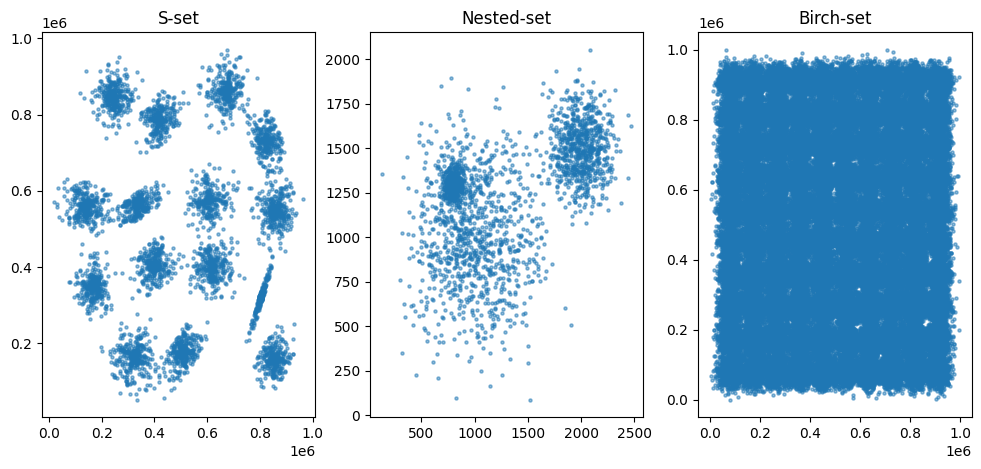

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].scatter(s_set[:, 0], s_set[:, 1], s=5, alpha=0.5)
axes[0].set_title("S-set")
axes[1].scatter(nested_set[:, 0], nested_set[:, 1], s=5, alpha=0.5)
axes[1].set_title("Nested-set")
axes[2].scatter(birch_set[:, 0], birch_set[:, 1], s=5, alpha=0.5)
axes[2].set_title("Birch-set")
plt.show()

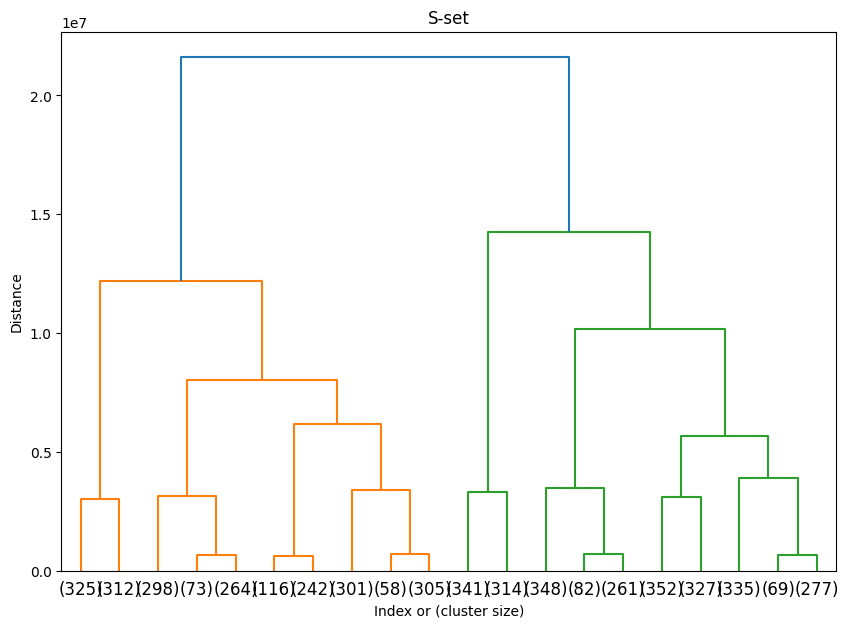

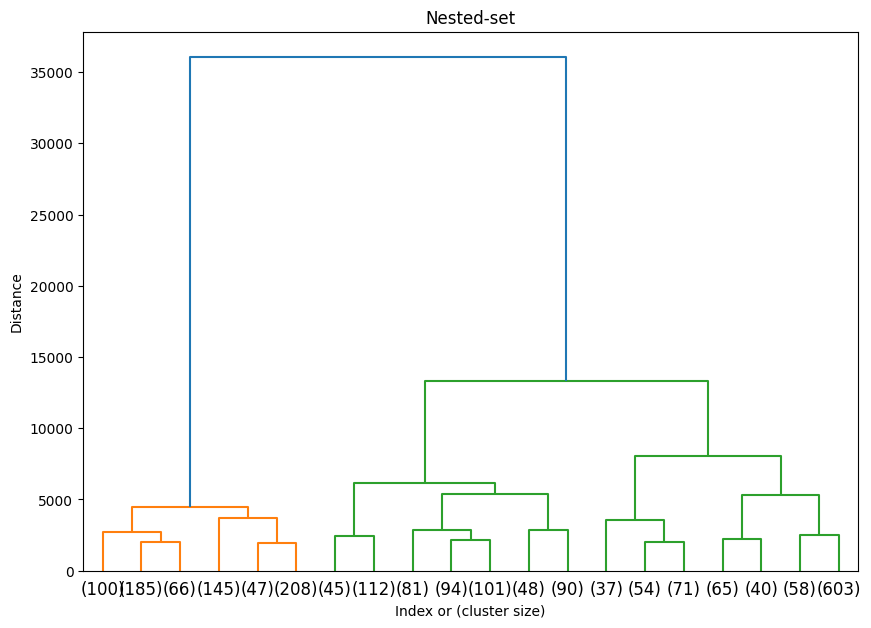

In [3]:
def plot_dendrogram(data, title, truncate_mode=None, p=30):
    plt.figure(figsize=(10, 7))
    plt.title(title)
    Z = linkage(data, method='ward')
    dendrogram(Z, truncate_mode=truncate_mode, p=p)
    plt.xlabel("Index or (cluster size)")
    plt.ylabel("Distance")
    plt.show()

plot_dendrogram(s_set, "S-set", truncate_mode='lastp', p=20)
plot_dendrogram(nested_set, "Nested-set", truncate_mode='lastp', p=20)
#plot_dendrogram(birch_set, "Birch-set", truncate_mode='lastp', p=20) => Za dużo RAMu

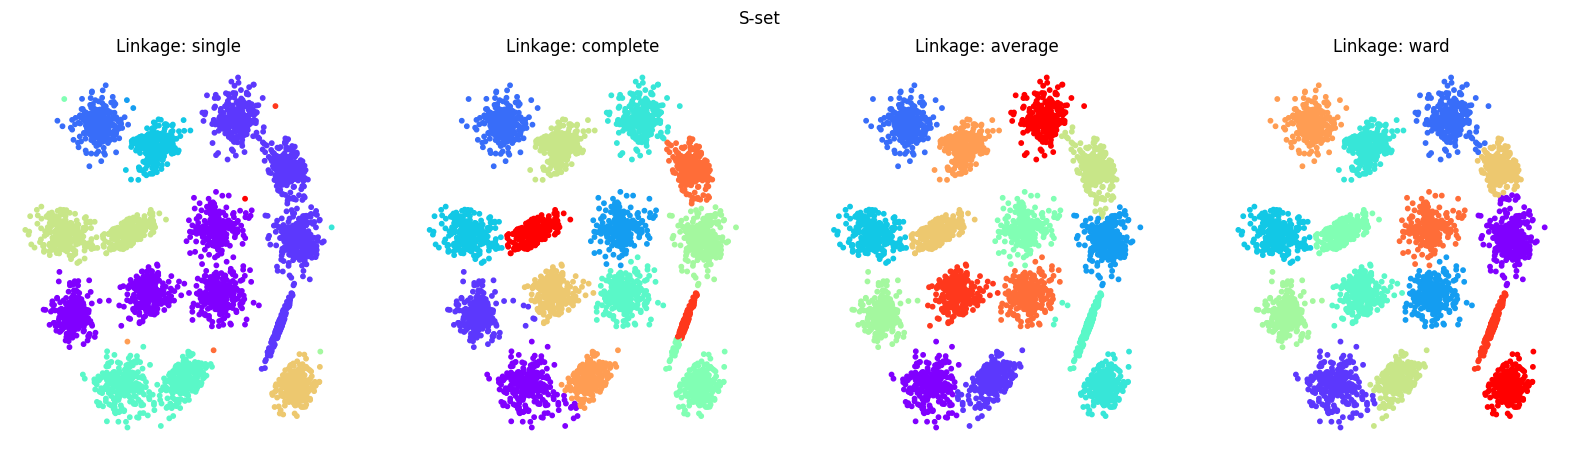

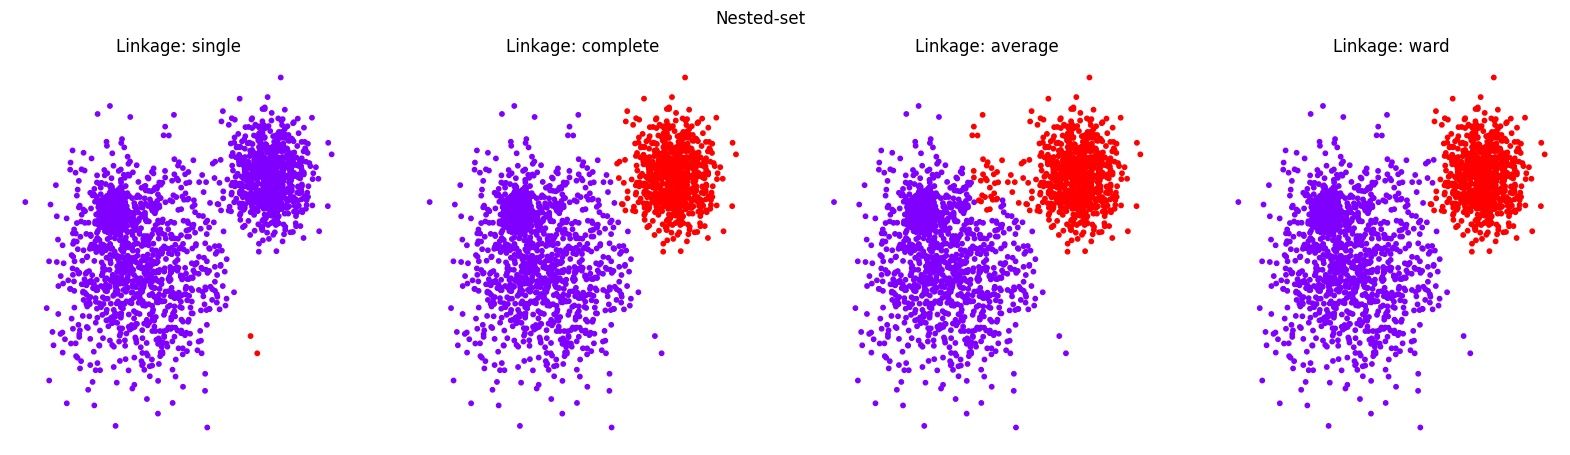

In [4]:
def test_linkages(data, n_clusters, title):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(title)
    
    for i, link in enumerate(['single', 'complete', 'average', 'ward']):
        ac = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage=link)
        labels = ac.fit_predict(data)
        
        axes[i].scatter(data[:, 0], data[:, 1], c=labels, s=10, cmap='rainbow')
        axes[i].set_title(f"Linkage: {link}")
        axes[i].axis('off')
    
    plt.show()

test_linkages(s_set, n_clusters=15, title="S-set")
test_linkages(nested_set, n_clusters=2, title="Nested-set")
# test_linkages(birch_set, n_clusters=100, title="Birch-set Sample")
# Zestaw był zbyt duży i wyłączył mi komputer :( => Powodem było zbyt duże zużycie RAM, więc nie możemy zastosować metody AgglomerativeClustering do tego zbioru danych.

W przypadku zbioru `S-set` najlepszy rezultat zapewniła wyłącznie metoda ward. Tuż za nią uplasowały się warianty complete oraz average, które charakteryzowały się jedynie niewielkimi błędami. Zdecydowanie najgorzej w tym zestawieniu wypada metoda single, co wynikało z jej tendencji do tworzenia zbyt dużych klastrów.

Z kolei dla zagnieżdżonego zbioru `Nested-set` najwyższą skuteczność i najlepsze wyniki odnotowano dla metod ward i complete. Metoda average nie poradziła sobie z odpowiednią separacją, błędnie mieszając ze sobą oba klastry. Największy zawód sprawiła jednak metoda single, która niemal całkowicie zignorowała właściwą strukturę danych, wydzielając jedynie dwa niewielkie podpunkty w prawym dolnym rogu przestrzeni.

Analiza `Birch-set` okazała się niemożliwa z uwagi na zbyt duże zużycie pamięci RAM, co uniemożliwiło przeprowadzenie testów dla tego zbioru danych.